# Халиков Сардорбек БФБО-03-24

In [1]:
# Базовые библиотеки
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt

# ML: разбиение, CV, метрики
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.inspection import permutation_importance

# Pipeline и препроцессинг
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Сохранение артефактов
import json
import joblib
from pathlib import Path

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
df['target'].value_counts(normalize=True)


target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

In [2]:
df = pd.read_csv("S06-hw-dataset-01.csv")

# первые строки
df.head()


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [7]:

df.describe()


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [5]:
df['target'].value_counts()


target
0    8119
1    3881
Name: count, dtype: int64

In [6]:
df['target'].value_counts(normalize=True)


target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

In [8]:
y = df['target']

# Выделяем признаки (убираем id и target)
X = df.drop(columns=['id', 'target'])

X.shape, y.shape


((12000, 28), (12000,))

In [11]:
# Разбиваем данные на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape



((9000, 28), (3000, 28))

Мы убрали id, потому что это просто идентификатор и он не несёт информации для предсказания.
target выделили отдельно, чтобы модель не подглядывала ответ

In [12]:
# Проверка распределения классов
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(target
 0    0.676556
 1    0.323444
 Name: proportion, dtype: float64,
 target
 0    0.676667
 1    0.323333
 Name: proportion, dtype: float64)

In [23]:
# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# Предсказания
y_pred_dummy = dummy.predict(X_test)

# Вероятности (нужны для ROC-AUC)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

# Метрики
dummy_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_dummy),
    "f1": f1_score(y_test, y_pred_dummy),
    "roc_auc": roc_auc_score(y_test, y_proba_dummy),
}

dummy_metrics



{'accuracy': 0.6766666666666666, 'f1': 0.0, 'roc_auc': np.float64(0.5)}

DummyClassifier всегда предсказывает самый частый класс,
поэтому accuracy выглядит неплохо, но F1 и ROC-AUC показывают,
что модель не различает классы

In [21]:
# Pipeline: масштабирование + логистическая регрессия
logreg_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

# Обучение
logreg_pipe.fit(X_train, y_train)

# Предсказания
y_pred_logreg = logreg_pipe.predict(X_test)
y_proba_logreg = logreg_pipe.predict_proba(X_test)[:, 1]

# Метрики
logreg_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_logreg),
    "f1": f1_score(y_test, y_pred_logreg),
    "roc_auc": roc_auc_score(y_test, y_proba_logreg),
}

logreg_metrics



{'accuracy': 0.8296666666666667,
 'f1': 0.7146845337800112,
 'roc_auc': np.float64(0.8789091463104972)}

LogisticRegression учитывает линейные зависимости между признаками
и показывает заметный прирост качества по сравнению с Dummy,
но не умеет хорошо ловить сложные нелинейности 

In [24]:
# Базовое дерево (без контроля сложности)
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

tree_metrics_raw = {
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "f1": f1_score(y_test, y_pred_tree),
    "roc_auc": roc_auc_score(y_test, y_proba_tree),
}

tree_metrics_raw


{'accuracy': 0.8566666666666667,
 'f1': 0.7767393561786086,
 'roc_auc': np.float64(0.8343354832156822)}

In [25]:
# Базовое дерево (без контроля сложности)
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

tree_metrics_raw = {
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "f1": f1_score(y_test, y_pred_tree),
    "roc_auc": roc_auc_score(y_test, y_proba_tree),
}

tree_metrics_raw


{'accuracy': 0.8566666666666667,
 'f1': 0.7767393561786086,
 'roc_auc': np.float64(0.8343354832156822)}

In [26]:
# Дерево с подбором гиперпараметров
tree_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

param_grid_tree = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
}

tree_search = GridSearchCV(
    tree_clf,
    param_grid_tree,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

tree_search.fit(X_train, y_train)

tree_search.best_params_, tree_search.best_score_


({'max_depth': None, 'min_samples_leaf': 20}, np.float64(0.9132029407664003))

max_depth — ограничивает глубину дерева

min_samples_leaf — не даёт листьям быть слишком маленькими

cv=5 — честный подбор только на train

roc_auc — основная метрика для бинарной задачи

In [27]:
best_tree = tree_search.best_estimator_

y_pred_tree = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

tree_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "f1": f1_score(y_test, y_pred_tree),
    "roc_auc": roc_auc_score(y_test, y_proba_tree),
}

tree_metrics


{'accuracy': 0.8633333333333333,
 'f1': 0.7848898216159497,
 'roc_auc': np.float64(0.9105332385353713)}

Random Forest (много деревьев, каждое видит свою подвыборку, уменьшается variance, модель становится стабильнее)

In [28]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_search.best_params_, rf_search.best_score_


({'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'n_estimators': 200},
 np.float64(0.968490366065778))

In [29]:
best_rf = rf_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
}

rf_metrics


{'accuracy': 0.933,
 'f1': 0.891644204851752,
 'roc_auc': np.float64(0.9703346706617236)}

In [30]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}

gb_search = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

gb_search.best_params_, gb_search.best_score_


({'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200},
 np.float64(0.9699186779757106))

In [31]:
best_gb = gb_search.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

gb_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "f1": f1_score(y_test, y_pred_gb),
    "roc_auc": roc_auc_score(y_test, y_proba_gb),
}

gb_metrics


{'accuracy': 0.934,
 'f1': 0.8943436499466382,
 'roc_auc': np.float64(0.9714763089736428)}

In [32]:
metrics_test = {
    "Dummy": dummy_metrics,
    "LogisticRegression": logreg_metrics,
    "DecisionTree": tree_metrics,
    "RandomForest": rf_metrics,
    "GradientBoosting": gb_metrics,
}

metrics_df = pd.DataFrame(metrics_test).T
metrics_df


,accuracy,f1,roc_auc
Dummy,0.676667,0.000000,0.500000
LogisticRegression,0.829667,0.714685,0.878909
DecisionTree,0.863333,0.784890,0.910533
RandomForest,0.933000,0.891644,0.970335
GradientBoosting,0.934000,0.894344,0.971476


Для бинарной классификации (dataset-01):

главный критерий - ROC-AUC

вторично смотрим на F1

accuracy - вспомогательная

Выбираю модель с максимальным ROC-AUC на test

In [35]:
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_name


'GradientBoosting'

Exception ignored in: <function ResourceTracker.__del__ at 0x106805bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1039c1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1025c9bc0>
Traceback (most recent call last

In [36]:
best_model = {
    "Dummy": dummy,
    "LogisticRegression": logreg_pipe,
    "DecisionTree": best_tree,
    "RandomForest": best_rf,
    "GradientBoosting": best_gb,
}[best_model_name]

best_model


GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42)

<Figure size 600x600 with 0 Axes>

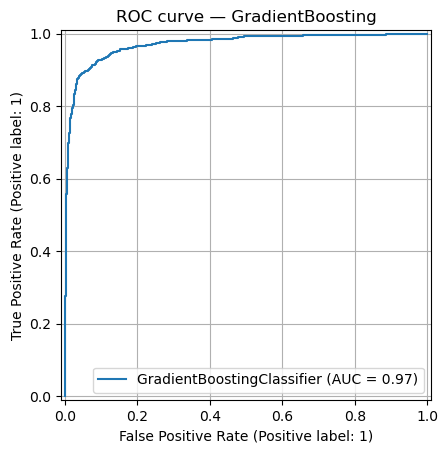

In [37]:
plt.figure(figsize=(6, 6))

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(f"ROC curve — {best_model_name}")
plt.grid(True)
plt.show()


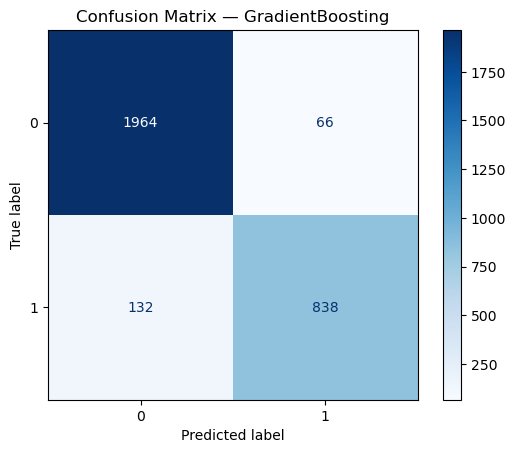

In [38]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


In [39]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importances = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)


num18    0.071444
num19    0.067091
num07    0.032075
num24    0.015176
num04    0.014335
num20    0.011499
num01    0.010407
num22    0.008423
num16    0.006676
num14    0.006397
dtype: float64

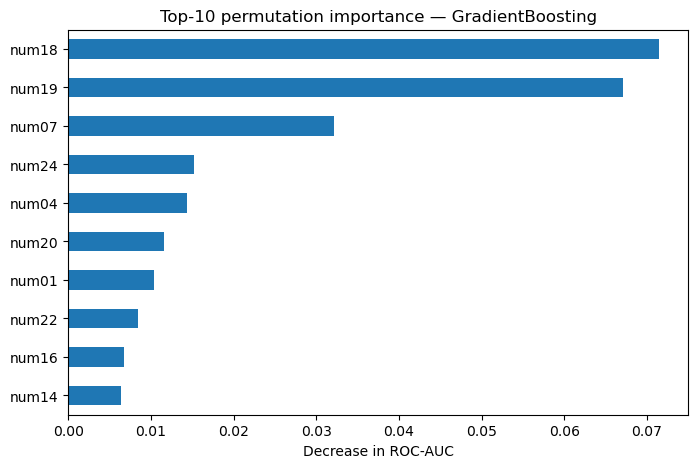

In [40]:
plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Top-10 permutation importance — {best_model_name}")
plt.xlabel("Decrease in ROC-AUC")
plt.show()


In [41]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)


In [42]:
with open(artifacts_dir / "metrics_test.json", "w") as f:
    json.dump(metrics_test, f, indent=2)


In [43]:
search_summaries = {
    "DecisionTree": {
        "best_params": tree_search.best_params_,
        "best_cv_score": tree_search.best_score_,
    },
    "RandomForest": {
        "best_params": rf_search.best_params_,
        "best_cv_score": rf_search.best_score_,
    },
    "GradientBoosting": {
        "best_params": gb_search.best_params_,
        "best_cv_score": gb_search.best_score_,
    },
}

with open(artifacts_dir / "search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=2)


In [44]:
joblib.dump(best_model, artifacts_dir / "best_model.joblib")


['artifacts/best_model.joblib']

In [45]:
best_model_meta = {
    "model": best_model_name,
    "metrics": metrics_test[best_model_name],
}

with open(artifacts_dir / "best_model_meta.json", "w") as f:
    json.dump(best_model_meta, f, indent=2)


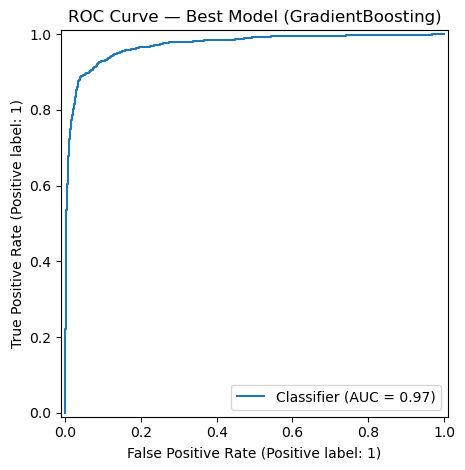

In [47]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_best
)

plt.title("ROC Curve — Best Model (GradientBoosting)")
plt.tight_layout()
plt.show()


In [48]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importances = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)

importances.head(10)


,feature,importance
17,num18,0.071444
18,num19,0.067091
6,num07,0.032075
23,num24,0.015176
3,num04,0.014335
19,num20,0.011499
0,num01,0.010407
21,num22,0.008423
15,num16,0.006676
13,num14,0.006397


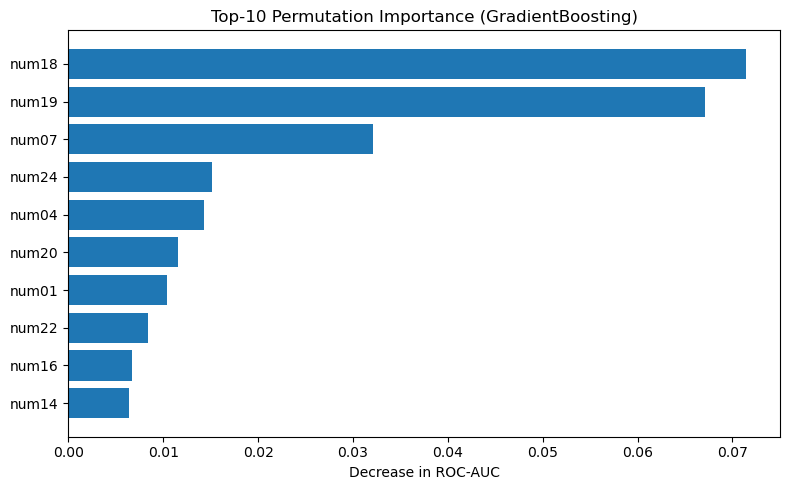

In [49]:
plt.figure(figsize=(8, 5))
plt.barh(
    importances.head(10)["feature"],
    importances.head(10)["importance"]
)
plt.gca().invert_yaxis()
plt.title("Top-10 Permutation Importance (GradientBoosting)")
plt.xlabel("Decrease in ROC-AUC")
plt.tight_layout()
plt.show()


In [50]:
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


In [51]:
disp.figure_.savefig(FIGURES_DIR / "confusion_matrix.png")


In [52]:
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.savefig(FIGURES_DIR / "roc_curve.png")
plt.close()


<Figure size 640x480 with 0 Axes>

In [53]:
metrics_df.to_json(
    ARTIFACTS_DIR / "metrics_test.json",
    orient="records",
    indent=2
)


In [54]:
joblib.dump(best_model, ARTIFACTS_DIR / "best_model.joblib")


['artifacts/best_model.joblib']

In [55]:
best_model_meta = {
    "model": best_model_name,
    "metrics": metrics_df.loc[best_model_name].to_dict(),
    "random_state": RANDOM_STATE
}

with open(ARTIFACTS_DIR / "best_model_meta.json", "w") as f:
    json.dump(best_model_meta, f, indent=2)
